<a href="https://colab.research.google.com/github/Thanyarat281-6/BSC_DPDM2025/blob/main/Huberregressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
%pip install torch_geometric

## Library Version 22_4 : Dropout between later, Dense graphs, USe Otograohic precitaiton edges caled from U, W CW, Dem and leedside windside, AttentionLSTM_V8, No Quantile Mapping, adaptive_huber_loss with percentile_loss to handle Extreme Events. Input includes calculated indices: PDO, ONI, SWM, DMI, and downloaded indices: MEIV2, BSISO, and MJO. , NEW NE index


In [5]:
import os
import pandas as pd
import numpy as np
import sys
import datetime
import copy
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle
import random
import matplotlib.pyplot as plt
import copy
from dateutil.relativedelta import relativedelta
import time
import inspect
import time as countdown
from tqdm import tqdm
import time as countdown
from torch_geometric.data import HeteroData




import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
from torch.nn import Parameter
from torch import Tensor


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [6]:

import os, sys

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Hyperparameters

In [7]:
algo='LSTM_V23_11'

num_epoch = 300
window_size = 24  #Window size
horizon = 12   #Prediction horizon
TBPTT_K = 24

learn_rate =0.001
weight_decay =1e-4
cluster =6 #choose cluster of the HII stations
k_fold_num=2
percentile_loss =0.95

# PARAMETERS FOR SMALL DATA
noise_level = 0.05  # Standard deviation of noise (5% of signal)

min_epochs = 20
patience = 100
LOG_EVERY = 20


hidden_size_list =[128]
num_layers_list =[2]
drop_out_list=[0.4]



## Load dataset

In [8]:
X_index = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/X_variable(Index)_operation_v4.csv')
Y_rainfall = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Y_variable(Rainfall).csv')
# Convert 'DATE' column in Y_df to datetime objects if it's not already
X_index['DATE'] = pd.to_datetime(X_index['DATE'])

# Format the dates in Y_df as 'YYYY-MM-01'
X_index['DATE'] = X_index['DATE'].dt.strftime('%Y-%m-01')



node = pd.read_csv('/content/drive/MyDrive/KKU_Workshop3/Node_table_TMD.csv')


path_feature = os.path.join("/content/drive/MyDrive/KKU_Workshop3/lookup_table_reanalysis_v5.csv")
feature = pd.read_csv(path_feature, header= "infer")



In [9]:
Y_rainfall = Y_rainfall.rename(columns={'code': 'Node'})

Y_rainfall_clean = Y_rainfall.copy()
num_feature = len(feature[feature['Cluster']==cluster])

In [10]:

def apply_time_lag(df, column_name, lag):
    # Create a new column name with the lag suffix
    new_column_name = f"{column_name}_lag{lag}"

    # Shift the column values by the specified lag
    df[new_column_name] = df[column_name].shift(lag)

    return df

# Define the time lags for each climate index

time_lags = {

    'MEIV2': [1, 2, 3],
    'RMM_AMPLITUDE': [1],
    'PHASE': [1],
    'PDO': [1, 2],
    'ONI': [1, 2],
    'DMI': [1, 2],
    'BSISO1': [1],
    'BSISO1-Phase': [1],
    'SWM': [1],

}




# Apply time lags to each specified column in df_merge_type
for column, lag in time_lags.items():
      if column in X_index.columns:
            for lag_item in lag:
                X_index = apply_time_lag(X_index, column, lag_item)
      else:
        print(f"Warning: Column '{column}' not found in df_merge_type. Skipping.")


Data cleansing

In [11]:
HQ_date_get_month_df  =  Y_rainfall.copy()
Y_rainfall_clean =  Y_rainfall.copy()
HQ_date_get_month_df['DATE'] = pd.to_datetime(Y_rainfall['DATE']).dt.month

month_avg_list = []
for month in range(1, 12 + 1):
    # Filter the data for the current year
    HQ_data = HQ_date_get_month_df[HQ_date_get_month_df['DATE'] == month]

    # Average rainfall
    av_r = HQ_data.iloc[:, 1:].median()

    # Create a dictionary to hold the data for this year
    month_dict = {'MONTH': month}
    month_dict.update(av_r)

    # Append the data for this year to the list
    month_avg_list.append(month_dict)

HQ_month_avg = pd.DataFrame(month_avg_list)

for i in range(1, len(Y_rainfall_clean.columns)):
    for j in range(0, len(Y_rainfall_clean)):
        if(np.isnan(Y_rainfall_clean.iloc[j, i])):
             Y_rainfall_clean.iloc[j, i] = HQ_month_avg.iloc[pd.to_datetime(Y_rainfall_clean.iloc[:, 0]).dt.month[j]-1, i]

In [12]:
Y_rainfall_clean['DATE'].max()

'2025-03-01'

In [13]:
start_training_date = '1982-01-01'


X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01
Maximum date possible :  2025-03-01 00:00:00


In [14]:
start_training_date = Y_rainfall_clean['DATE'].min()

X_index['DATE'] = pd.to_datetime(X_index['DATE'])
Y_rainfall_clean['DATE'] = pd.to_datetime(Y_rainfall_clean['DATE'])
max_date_X = X_index['DATE'].max()
max_date_Y = Y_rainfall_clean['DATE'].max()
# Minimum date possible

print("Maximum date possible : ",start_training_date)


# Maximum date possible
max_date_possible = min([max_date_X,max_date_Y])
print("Maximum date possible : ",max_date_possible)

#Make condition
con_date_X = (X_index['DATE'] >= start_training_date) & (X_index['DATE'] <= max_date_possible)
con_date_Y = (Y_rainfall_clean['DATE'] >= start_training_date) & (Y_rainfall_clean['DATE'] <= max_date_possible)

#Final select
X_index_interval_date = X_index.loc[con_date_X,:]
Y_rainfall_clean = Y_rainfall_clean.loc[con_date_Y,:]


Y_rainfall_interval_date = copy.deepcopy(Y_rainfall_clean)

Maximum date possible :  1982-01-01 00:00:00
Maximum date possible :  2025-03-01 00:00:00


In [15]:
#Count null value of each indexs
print("Number of index columns which contain null value : ",len(X_index_interval_date.isnull().sum()[X_index_interval_date.isnull().sum()>0]), sep="")
print("Number of rainfall station which contain null value : ",len(Y_rainfall_interval_date.isnull().sum()[Y_rainfall_interval_date.isnull().sum()>0]), sep="")

Number of index columns which contain null value : 0
Number of rainfall station which contain null value : 0


## Convert DATE columns to index columns

In [16]:
def convert_columns_to_index_columns(df,col_name):
    df.loc[:,col_name] = pd.to_datetime(df[col_name])
    df = df.set_index(col_name, inplace=False)
    return df

- independend variable dataframe

In [17]:
X_index_df_ready = convert_columns_to_index_columns(X_index_interval_date, 'DATE')
Y_rainfall_df_ready = convert_columns_to_index_columns(Y_rainfall_interval_date, 'DATE')

In [18]:
print("nrow of X : {}".format(X_index_df_ready.shape[0]))
print("nrow of Y : {}".format(X_index_df_ready.shape[0]))

nrow of X : 519
nrow of Y : 519


## Standardize

In [19]:

#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()

X_normalize_data = scaler_X.fit_transform(X_index_df_ready)
X_index_normalized_df = pd.DataFrame(X_normalize_data, columns=X_index_df_ready.columns)

scaler_Y = StandardScaler()

Y_normalize_data = scaler_Y.fit_transform(Y_rainfall_df_ready)
Y_rainfall_normalized_df = pd.DataFrame(Y_normalize_data, columns=Y_rainfall_df_ready.columns)

In [20]:

# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'wb') as file:
    pickle.dump(scaler_Y, file)
# Save the scaler
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_X.pkl', 'wb') as file:
    pickle.dump(scaler_X, file)


# Load the scaler for inference
with open('/content/drive/MyDrive/KKU_Workshop3/scaler_Y.pkl', 'rb') as file:
    scaler_Y = pickle.load(file)

## Summarises all climate index

In [21]:
#Get date range from original files because after normalization index will reset
og_date_range = X_index_interval_date['DATE']
X_index_normalized_df.set_index(og_date_range, inplace=True)
Y_rainfall_normalized_df.set_index(og_date_range, inplace=True)

n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  24
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1'],
      dtype='object')


## Add cos sin function to X

### Combine static feature

In [22]:
X_index_normalized_df['Month_sin'] = np.sin(2 * np.pi * X_index_normalized_df.index.month / 12)
X_index_normalized_df['Month_cos'] = np.cos(2 * np.pi * X_index_normalized_df.index.month / 12)

In [23]:
station_id_list = Y_rainfall_normalized_df.columns
list_table = []
for code_st in station_id_list:
  #print(code_st)

  #print(static_value)
  eindices_df = X_index_normalized_df.copy()



  eindices_df[code_st] = Y_rainfall_normalized_df[code_st]

  list_table.append(eindices_df)

In [24]:
n_feature_climate = X_index_normalized_df.shape[1]
feature_climate = X_index_normalized_df.columns
print("Number of climate index feature : ",n_feature_climate)
print("All climate index : \n",feature_climate)

Number of climate index feature :  26
All climate index : 
 Index(['MEIV2', 'RMM_AMPLITUDE', 'PHASE', 'BSISO1', 'BSISO1-Phase', 'DMI',
       'ONI', 'PDO', 'SWM', 'NE', 'MEIV2_lag1', 'MEIV2_lag2', 'MEIV2_lag3',
       'RMM_AMPLITUDE_lag1', 'PHASE_lag1', 'PDO_lag1', 'PDO_lag2', 'ONI_lag1',
       'ONI_lag2', 'DMI_lag1', 'DMI_lag2', 'BSISO1_lag1', 'BSISO1-Phase_lag1',
       'SWM_lag1', 'Month_sin', 'Month_cos'],
      dtype='object')


## Split dataframe to add static feature

### Import meta data

### Add new date and latitude-longitude format columns

## Split training and testing

### Define start and end date of each interval

# Train Fold 1 = 2018-2020, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 2018-2022, Val = 2021-2023, Test = 1/2022 - 12/2024

In [25]:
#Train interval

start_interval_train1 =  pd.to_datetime(min(Y_rainfall_normalized_df.index))
#maximum_interval_train = max(Y_rainfall_normalized_df.index[0:-6])


end_interval_train1 = start_interval_train1 + relativedelta(months=37*12+11)


#Test1 interval
start_interval_val1 = start_interval_train1 + relativedelta(months=36*12)
end_interval_val1 =  start_interval_train1 + relativedelta(months=38*12+11)



#Test1 interval
start_interval_test1 = start_interval_train1 + relativedelta(months=37*12)
end_interval_test1 = start_interval_train1 + relativedelta(months=39*12+11)
#end_interval_test = start_interval_test + relativedelta(months=backward_months+17)
#Display
print("############################################################")
print("TRAINING Fold 1")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train1)

print("############################################################")
print("VALIDATION Fold 1")
print('Start interval date of testing set: ', start_interval_val1)
print('End interval date of testing set :', end_interval_val1)
print("############################################################")



print("############################################################")
print("TESTING Fold 1")
print('Start interval date of testing set: ', start_interval_test1)
print('End interval date of testing set :', end_interval_test1)
print("############################################################")
#if cluster in [4 ,5,6,7, 8,9 ,10,11,12]:
#    start_interval_train1 = start_interval_val1 +  relativedelta(months=1)

#    end_interval_train2 = start_interval_train1 +  relativedelta(months=4*12+12)


    #Train interval
#    start_interval_val2 = start_interval_train1 +  relativedelta(months=3*12-1)
#    end_interval_val2 = start_interval_train1 +  relativedelta(months=5*12+10)



    #Test2 interval
#    start_interval_test2 = start_interval_train1 +  relativedelta(months=3*12+9)
#    end_interval_test2 = start_interval_train1 +  relativedelta(months=6*12+11-3)

#else:
start_interval_train1 = start_interval_train1

end_interval_train2 = start_interval_train1 + relativedelta(months=40*12)


    #Train interval
start_interval_val2 = start_interval_train1  + relativedelta(months=39*12)
end_interval_val2 = start_interval_train1 + relativedelta(months=41*12+11)



    #Test2 interval
start_interval_test2 = start_interval_train1 + relativedelta(months=40*12)
end_interval_test2 = start_interval_train1 + relativedelta(months=42*12+11)


#Display
print("############################################################")
print("TRAINING Fold 2")
print('Start interval date of training set: ', start_interval_train1)
#print('Maximum interval date : ', maximum_interval_train)
print('End interval date of training set :', end_interval_train2)

print("############################################################")
print("VALIDATION Fold 2")
print('Start interval date of testing set: ', start_interval_val2)
print('End interval date of testing set :', end_interval_val2)
print("############################################################")



print("############################################################")
print("TESTING Fold 2")
print('Start interval date of testing set: ', start_interval_test2)
print('End interval date of testing set :', end_interval_test2)
print("############################################################")

# Train Fold 1 = 1982-2019, Val = 2018-2020, Test = 2019 - 2021

# Train Fold 2 = 1982-2022, Val = 2021-2023, Test = 2022 - 2024

############################################################
TRAINING Fold 1
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2019-12-01 00:00:00
############################################################
VALIDATION Fold 1
Start interval date of testing set:  2018-01-01 00:00:00
End interval date of testing set : 2020-12-01 00:00:00
############################################################
############################################################
TESTING Fold 1
Start interval date of testing set:  2019-01-01 00:00:00
End interval date of testing set : 2021-12-01 00:00:00
############################################################
############################################################
TRAINING Fold 2
Start interval date of training set:  1982-01-01 00:00:00
End interval date of training set : 2022-01-01 00:00:00
############################################################
VALIDATION Fold 2
Start interval date of testing set:  2

### Split training and testing

In [26]:
#Split test and train

Train_df_list1, Val_df_list1, Test_df_list1,Train_df_list2,  Val_df_list2 ,Test_df_list2 = [], [],[],[],[],[]
for i_table in range(len(list_table)):
  Train_df_list1.append(list_table[i_table][start_interval_train1:end_interval_train1])
  Val_df_list1.append(list_table[i_table][start_interval_val1:end_interval_val1])
  Test_df_list1.append(list_table[i_table][start_interval_test1:end_interval_test1])
  Train_df_list2.append(list_table[i_table][start_interval_train1:end_interval_train2])
  Val_df_list2.append(list_table[i_table][start_interval_val2:end_interval_val2])
  Test_df_list2.append(list_table[i_table][start_interval_test2:end_interval_test2])

fold =[]
fold.append([Train_df_list1,Test_df_list1,Val_df_list1])
fold.append([Train_df_list2,Test_df_list2,Val_df_list2])


In [27]:
Train_df_list1


[               MEIV2  RMM_AMPLITUDE     PHASE    BSISO1  BSISO1-Phase  \
 DATE                                                                    
 1982-01-01 -0.187714       0.714459 -1.386540 -0.948166     -0.832762   
 1982-02-01 -0.102040       0.281839  1.174365 -0.948166     -0.832762   
 1982-03-01 -1.056691       0.443087  0.747548 -0.948166     -0.832762   
 1982-04-01 -0.261148       0.738476  1.601183 -0.948166     -0.832762   
 1982-05-01 -0.579365      -0.930963 -0.532905  0.774939     -0.170381   
 ...              ...            ...       ...       ...           ...   
 2019-08-01 -0.322344      -0.930963 -0.106088  1.268179      1.154380   
 2019-09-01 -0.518170      -0.930963 -1.386540  0.932615      0.823190   
 2019-10-01 -0.334583      -0.930963 -0.959723  0.717530      1.816761   
 2019-11-01 -0.138757       1.058389  0.320730 -0.948166     -0.832762   
 2019-12-01 -0.273387       0.323061 -0.959723 -0.948166     -0.832762   
 
                  DMI       ONI     

In [28]:
Test_df_list1

[               MEIV2  RMM_AMPLITUDE     PHASE    BSISO1  BSISO1-Phase  \
 DATE                                                                    
 2019-01-01 -0.603844       1.312648  0.320730 -0.948166     -0.832762   
 2019-02-01 -0.102040       0.914240  1.601183 -0.948166     -0.832762   
 2019-03-01  0.216177       1.180326 -0.106088 -0.948166     -0.832762   
 2019-04-01 -0.346822       1.211537 -0.959723 -0.948166     -0.832762   
 2019-05-01 -0.432496      -0.930963 -0.959723  1.540674      1.816761   
 2019-06-01 -0.285627      -0.930963 -0.959723  0.751490     -0.170381   
 2019-07-01 -0.346822      -0.930963 -1.386540  0.562280      1.154380   
 2019-08-01 -0.322344      -0.930963 -0.106088  1.268179      1.154380   
 2019-09-01 -0.518170      -0.930963 -1.386540  0.932615      0.823190   
 2019-10-01 -0.334583      -0.930963 -0.959723  0.717530      1.816761   
 2019-11-01 -0.138757       1.058389  0.320730 -0.948166     -0.832762   
 2019-12-01 -0.273387       0.323061 -

# Feature selection part

## Focus only feature of climate

In [29]:
print("The first feature size that is climate index:", n_feature_climate)

The first feature size that is climate index: 26


In [30]:
selected_index =[]
feature_cluster =  feature[feature['Cluster']==cluster]
for feature_index in range(len(feature_cluster)):
    for i in range(len(feature_climate)):
        if((feature_climate[i] == feature_cluster.iloc[feature_index,1]) and feature_cluster.iloc[feature_index,5] == 0):
                selected_index.append(i)

        elif(feature_cluster.iloc[feature_index,5] != 0):
            for i_lag in range(len(feature_climate)):
                if(feature_climate[i_lag] == feature_cluster.iloc[feature_index,1]+'_lag'+str(feature_cluster.iloc[feature_index,5])):
                    selected_index.append(i_lag)
                    break
                else:
                    continue  # Continue if the inner loop wasn't broken.
            break  # Inner loop was broken, break the outer.

selected_index.sort()
feature_climate[selected_index]


Index(['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin',
       'Month_cos'],
      dtype='object')

## Feature selection
- Create binary position (length = climate feature)

In [31]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [0, 0, 1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 17, 24, 25, 28]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


## Select columns by position vector (position_all)

In [32]:
random.seed(10)
position_optimal = [0 for i in range(n_feature_climate)]
#position_remain = (Train_df_list[0].shape[1] - n_feature_climate)*[1]
position_remain = [1] # select rain

for id in selected_index:
  position_optimal[id]=1

position_all = position_optimal + position_remain
position_all_index = [index for index,value in enumerate(position_all) if value == 1]
climate_name_list = [feature_climate[index] for index,value in enumerate(position_optimal) if value == 1]

print("position_all_index : ", position_all_index)
print("Climate index : ", climate_name_list)

position_all_index :  [1, 3, 5, 8, 9, 17, 24, 25, 26]
Climate index :  ['RMM_AMPLITUDE', 'BSISO1', 'DMI', 'SWM', 'NE', 'ONI_lag1', 'Month_sin', 'Month_cos']


In [33]:
def select_feature_f(list_df,position_feature_index):
    for i in range(len(list_df)):
        list_df[i] = list_df[i].iloc[:,position_feature_index]
    return list_df

In [34]:
#Fold 1 = Fold[0] , Fold 2 = Fold[1]
#Test Fold 1 = Fold[0][0] , Train Fold 1 = Fold[0][1], Validation Fold 1 = Fold[0][2]
fold[0][0] = select_feature_f(list_df = fold[0][0], position_feature_index = position_all_index)
fold[0][1] = select_feature_f(list_df = fold[0][1], position_feature_index = position_all_index)
fold[0][2] = select_feature_f(list_df = fold[0][2], position_feature_index = position_all_index)
fold[1][0] = select_feature_f(list_df = fold[1][0], position_feature_index = position_all_index)
fold[1][1] = select_feature_f(list_df = fold[1][1], position_feature_index = position_all_index)
fold[1][2] = select_feature_f(list_df = fold[1][2], position_feature_index = position_all_index)

In [35]:
len(Y_rainfall_normalized_df.columns)

132

## Read node location

In [36]:
cluster_station= []
for index in range(0,len(Y_rainfall_normalized_df.columns)):
    if (node['quality'].iloc[index]==1 and node['cluster'].iloc[index]==cluster) :
            cluster_station.append(index)


In [37]:
for index in range(len(cluster_station)):
    print(node['Node'].iloc[cluster_station[index]])

351201
376201
376202
376401
378201
379201
379401


Create node

Creat training test set for each station

Create static features

In [38]:
num_feature = len(feature[feature['Cluster']==cluster])

## Check edges

In [39]:

def extract_features(feature,j, window_size,horizon,data_list):
    xs_list= []
    for station in cluster_station:
        xs_new= np.array(data_list[station].iloc[:,feature][j:j+window_size])
        xs_list.append([xs_new])
    xs = np.array(xs_list)
    return xs

In [40]:
climate_name_list

['RMM_AMPLITUDE',
 'BSISO1',
 'DMI',
 'SWM',
 'NE',
 'ONI_lag1',
 'Month_sin',
 'Month_cos']

Add snapshot signal in = Windows , out = 12

Train_df_listCreate edges

In [41]:
num_feature

8

Convert to homogenious structure

In [42]:


# Station id
s=0



#Sliding window Train
fold_tensor = copy.deepcopy(fold)

for fold_index in range(k_fold_num):
    train_set =[]
    train= HeteroData()

    test_set =[]
    test= HeteroData()

    val_set =[]
    val = HeteroData()


    for j in range(len(fold[fold_index][0][s]) - window_size - horizon + 1):
        # if j%(window_size-1)==0: #
        #if j%3==0: #
        tan_x=[]
        rain_fall_x=[]
        rain_fall_y=[]

        for station in cluster_station:
            tan_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][0][station][fold[fold_index][0][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            train[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][0]), dtype=torch.float32)
        train['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        train['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)

        train_set.append(copy.deepcopy(train))

    fold_tensor[fold_index][0] = train_set
    #Sliding window Test

    for j in range(len(fold[fold_index][1][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][1][station][fold[fold_index][1][station].columns[-1]][j+window_size:j+window_size+horizon])])


        for climate_index in range(len(climate_name_list)):

            test[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][1]), dtype=torch.float32)


        test['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        test['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)


        test_set.append(copy.deepcopy(test))

    fold_tensor[fold_index][1] = test_set


    for j in range(len(fold[fold_index][2][s]) - window_size - horizon + 1):
        tan_x =[]
        rain_fall_x=[]
        rain_fall_y=[]
        for station in cluster_station:
            tan_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-2]][j:j+window_size])])
            rain_fall_x.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j:j+window_size])])
            rain_fall_y.append([(fold[fold_index][2][station][fold[fold_index][2][station].columns[-1]][j+window_size:j+window_size+horizon])])

        for climate_index in range(len(climate_name_list)):
            val[climate_name_list[climate_index]].x = torch.tensor(extract_features(climate_index,j, window_size,horizon,fold[fold_index][2]), dtype=torch.float32)

        val['station'].x = torch.tensor(np.array(rain_fall_x), dtype=torch.float32)
        val['station'].y = torch.tensor(np.array(rain_fall_y), dtype=torch.float32)



        val_set.append(copy.deepcopy(val))

    fold_tensor[fold_index][2] = val_set



In [43]:
def extract_x(data):
    datax =[]
    i=0
    cluster_i=0
    for feature_index in range((num_feature)):

        datax.append([data.x[i][0].detach().cpu().numpy()])
        i=i+len(cluster_station)
    #result = torch.cat(datax, dim=1)
    for cluster_index in range(len(cluster_station)):

        datax.append([data.x[i+cluster_i][0].detach().cpu().numpy()])
        cluster_i=cluster_i+1
    return datax


In [44]:

def accuracy2D_classic(y_pred, y_target):
    y_pred=y_pred.detach().cpu().numpy()
    y_target=y_target.detach().cpu().numpy()
    y_pred =np.reshape(y_pred,y_pred.shape[0]*y_pred.shape[1])
    y_target =np.reshape(y_target,y_target.shape[0]*y_target.shape[1])
    a = [1-min(1,abs((j-i)/i)) for j,i in zip(y_pred, y_target) if i !=0]
    for i in range(len(y_target)):
        if y_target[i]==0:
            a[i] = 1-min(1,2*abs(y_pred[i]-y_target[i])/abs(y_pred[i]+y_target[i]))

    return np.array(a)

In [45]:
def transformback_future(pred,station,n):

    preds_temp = np.ones(Y_normalize_data.shape)
    for i in range(len(pred)):
        preds_temp[Y_normalize_data.shape[0]-n+i,station] =pred[pred.shape[0]-n+i]
    preds_values = scaler_Y.inverse_transform(preds_temp)
    preds_value = preds_values[preds_values.shape[0]-n:preds_values.shape[0],station]
    return (preds_value)

In [46]:
import torch
from typing import Dict, Union, List

def nse_per_station(observations, predictions, station_indices=None):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) for each station separately.

    Args:
        observations (torch.Tensor): Ground truth values, shape (num_stations, num_timesteps).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.
        station_indices (Dict[str, int], optional): Dictionary mapping station names to their
                                                  indices in the tensors.

    Returns:
        Dict[str, float]: Nash-Sutcliffe Efficiency (NSE) score for each station.
    """
    # Ensure inputs have the correct shape
    if observations.dim() != 2 or predictions.dim() != 2:
        raise ValueError("Inputs must be 2D tensors with shape (num_stations, num_timesteps)")

    if observations.shape != predictions.shape:
        raise ValueError(f"Shape mismatch: observations {observations.shape}, predictions {predictions.shape}")

    num_stations = observations.shape[0]

    # Initialize results dictionary
    if station_indices is None:
        # If no station names provided, use numerical indices
        station_indices = {str(i): i for i in range(num_stations)}

    nse_scores = {}

    # Calculate NSE for each station
    for station_name, idx in station_indices.items():
        # Get data for this station
        station_obs = observations[idx]
        station_pred = predictions[idx]

        # Skip stations with NaN values if needed
        if torch.isnan(station_obs).any() or torch.isnan(station_pred).any():
            # Handle NaN values by filtering them out
            valid_mask = ~(torch.isnan(station_obs) | torch.isnan(station_pred))
            station_obs = station_obs[valid_mask]
            station_pred = station_pred[valid_mask]

            # Skip if no valid data points remain
            if len(station_obs) == 0:
                nse_scores[station_name] = float('nan')
                continue

        # Calculate mean of observations for THIS STATION only
        mean_obs = torch.mean(station_obs)

        # Compute numerator (sum of squared residuals)
        numerator = torch.sum((station_obs - station_pred) ** 2)

        # Compute denominator (sum of squared deviations from mean of observations)
        denominator = torch.sum((station_obs - mean_obs) ** 2)

        # Avoid division by zero
        if denominator == 0:
            # If predictions match observations exactly when they're all the same value
            if numerator == 0:
                nse_scores[station_name] = 1.0
            else:
                nse_scores[station_name] = float('nan')  # NSE undefined
        else:
            # Compute NSE for this station
            station_nse = 1 - (numerator / denominator)
            nse_scores[station_name] = station_nse.item()

    return nse_scores



In [47]:
def adaptive_huber_loss(y_pred, y_true, delta=1.0):
    """
    Huber loss with adaptive delta parameter based on data distribution

    Args:
        y_pred: Model predictions
        y_true: Ground truth values
        delta: Threshold parameter that determines quadratic vs. linear loss regions
    """
    # Calculate absolute error
    abs_error = torch.abs(y_pred - y_true)

    # Adapt delta based on data distribution (e.g., use 90th percentile)
    if delta is None:
        delta = torch.quantile(abs_error.detach(), 0.9)

    # Apply Huber loss formula
    quadratic_mask = (abs_error <= delta)
    linear_mask = ~quadratic_mask

    quadratic_loss = 0.5 * (abs_error ** 2)
    linear_loss = delta * (abs_error - 0.5 * delta)

    return torch.mean(quadratic_mask * quadratic_loss + linear_mask * linear_loss)

In [48]:
def nse(observations, predictions):
    """
    Compute the Nash-Sutcliffe Efficiency (NSE) between observed and predicted values.

    Args:
        observations (torch.Tensor): Ground truth values, shape (batch_size, ...).
        predictions (torch.Tensor): Predicted values, same shape as `observations`.

    Returns:
        float: Nash-Sutcliffe Efficiency (NSE) score.
    """


    # Calculate the mean of observed values
    mean_obs = np.mean(observations)

    # Compute numerator (sum of squared residuals)
    numerator = np.sum((observations - predictions) ** 2)

    # Compute denominator (sum of squared deviations from mean of observations)
    denominator = np.sum((observations - mean_obs) ** 2)

    # Avoid division by zero
    if denominator == 0:
        return float('nan')  # NSE cannot be computed if observations have zero variance

    # Compute and return NSE
    nse_score = 1 - (numerator / denominator)
    return nse_score.item()  # Convert to Python float for readability


In [49]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def inverse_transform_station_with_nans(scaled_predictions, station_index, scaler_object):
    """
    Efficiently transforms scaled predictions for a single station that may contain NaN
    values, using a multi-feature scaler. NaNs in the input are preserved as NaNs
    in the output.

    Args:
        scaled_predictions (np.ndarray):
            A 1D NumPy array containing the scaled predictions (and potentially NaNs)
            for a single station.

        station_index (int):
            The column index of the station that these predictions belong to.

        scaler_object (object):
            The multi-feature scikit-learn scaler object (e.g., MinMaxScaler) that
            was fitted on the complete, original dataset.

    Returns:
        np.ndarray:
            A 1D NumPy array of the same size as the input, with predictions in their
            original scale and NaNs preserved in their original positions.
    """
    # --- 1. Identify the locations of valid data and NaNs ---
    # Create a boolean mask to find where the valid numbers are.
    valid_mask = ~np.isnan(scaled_predictions)

    # Extract only the valid, non-NaN scaled prediction values.
    valid_scaled_preds = scaled_predictions[valid_mask]

    # If there are no valid values to transform, return the original array.
    if valid_scaled_preds.size == 0:
        return scaled_predictions

    # --- 2. Use the dummy array trick ONLY for the valid data ---
    # Get the total number of features (stations) the scaler was trained on.
    n_features = scaler_object.n_features_in_

    # Create a small dummy array. Its height is the number of *valid* predictions.
    # Its width is the total number of features.
    dummy_array = np.zeros((len(valid_scaled_preds), n_features))

    # Inject the valid predictions into the correct station's column.
    dummy_array[:, station_index] = valid_scaled_preds

    # --- 3. Perform the inverse transformation ---
    # This is efficient as it only transforms the valid data points.
    unscaled_dummy_array = scaler_object.inverse_transform(dummy_array)

    # Extract the now unscaled *valid* predictions from the correct column.
    unscaled_valid_preds = unscaled_dummy_array[:, station_index]

    # --- 4. Re-insert the transformed values back into a full-sized array ---
    # Create a new array of the original size, filled with NaNs.
    final_predictions = np.full_like(scaled_predictions, np.nan, dtype=float)

    # Use the boolean mask from step 1 to place the unscaled valid values
    # back into their original positions.
    final_predictions[valid_mask] = unscaled_valid_preds

    return final_predictions

In [50]:
def quantile_mapper(value, historical_preds, historical_obs):
        """
        Maps a value from the prediction distribution to the observation distribution.

        Args:
            value (float): The predicted value to be corrected (in mm).
            historical_preds (np.array): Sorted array of historical predictions.
            historical_obs (np.array): Sorted array of historical observations.

        Returns:
            float: The corrected value in mm.
        """
        # Find the percentile of the predicted value
        percentile = percentileofscore(historical_preds, value)

        # Find the corresponding value at that percentile in observations
        corrected_value = np.percentile(historical_obs, percentile, method='closest_observation')

        return corrected_value

In [51]:
len(cluster_station)

7

# Geometric Temporal Torch Model

Which model to choose depends on which time-series task you work on.

- AttentionGCN-GRU is an enhancement of GCN-LTSM that uses attention
- The spatial aggregation uses GCN, the temporal aggregation a GRU
- We can pass in periods to get an embedding for several timesteps
- This embedding can be used to predict several steps into the future = output dimension

Model Attention : An implementation of the Attention Graph Convolutional Cell. For details see this paper: “GRAPH ATTENTION NETWORKS” https://arxiv.org/pdf/1710.10903


In [52]:
import numpy as np
import torch
import matplotlib.pyplot as plt

class EarlyStopping:
    """
    Early stopping handler for PyTorch training with loss history plotting.
    - Saves best model whenever val_metric improves AFTER min_epochs.
    - Stops only after `min_epochs` and patience exceeded.
    """
    def __init__(
        self,
        patience=7,
        min_delta=0.0,
        mode='min',
        save_path=None,
        verbose=False,
        min_epochs=min_epochs,     # ✅ do not track best or early-stop before this epoch
    ):
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.mode = str(mode).lower()
        assert self.mode in ("min", "max"), "mode must be 'min' or 'max'"
        self.save_path = save_path
        self.verbose = bool(verbose)
        self.min_epochs = int(min_epochs)

        self.counter = 0
        self.best_score = None
        self.early_stop = False

        self.val_best = np.inf if self.mode == 'min' else -np.Inf

        # history
        self.val_loss_history = []
        self.train_loss_history = []
        self.epochs_history = []

    def _is_improvement(self, val_metric: float) -> bool:
        if self.best_score is None:
            return True

        if self.mode == 'min':
            return val_metric < (self.val_best - self.min_delta)
        else:
            return val_metric > (self.val_best + self.min_delta)

    def __call__(self, val_metric, train_metric, model, epoch):
        val_metric = float(val_metric)
        train_metric = float(train_metric)
        epoch = int(epoch)

        self.val_loss_history.append(val_metric)
        self.train_loss_history.append(train_metric)
        self.epochs_history.append(epoch)

        # ✅ FIXED: Completely ignore checkpointing & stopping logic before min_epochs
        if epoch < self.min_epochs:
            return False

        improved = self._is_improvement(val_metric)

        if improved:
            self.val_best = val_metric
            self.best_score = -val_metric if self.mode == 'min' else val_metric

            self.save_checkpoint(val_metric, model, epoch)

            self.counter = 0
        else:
            if self.best_score is not None:
                self.counter += 1
                if self.verbose:
                    print(f'EarlyStopping counter: {self.counter} out of {self.patience}')

        if self.counter >= self.patience:
            self.early_stop = True

        return self.early_stop

    def plot_loss_history(self, save_plot=True):
        plt.figure(figsize=(10, 6))
        plt.plot(self.epochs_history, self.train_loss_history, label='Training Loss', marker='o')
        plt.plot(self.epochs_history, self.val_loss_history, label='Validation Loss', marker='s')

        # ✅ FIXED: Only mark the "Best Val" from epochs >= min_epochs
        if len(self.val_loss_history) > 0:
            offset = min(self.min_epochs, len(self.val_loss_history) - 1)
            valid_hist = self.val_loss_history[offset:]

            if len(valid_hist) > 0:
                if self.mode == "min":
                    best_epoch_idx = offset + int(np.argmin(valid_hist))
                else:
                    best_epoch_idx = offset + int(np.argmax(valid_hist))

                best_val = float(self.val_loss_history[best_epoch_idx])
                best_epoch = self.epochs_history[best_epoch_idx]

                plt.axvline(x=best_epoch, color='r', linestyle='--', alpha=0.5)

                plt.annotate(
                    f'Best Val: {best_val:.4f}',
                    xy=(best_epoch, best_val),
                    xytext=(10, 10),
                    textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5),
                    arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0')
                )

        plt.title('Training and Validation Loss Over Time')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        if save_plot and self.save_path is not None:
            plt.savefig(self.save_path + '_loss_history.png')

    def save_checkpoint(self, val_metric, model, epoch):
        """Saves model when validation metric improves."""
        if self.save_path is None:
            return

        if self.verbose:
            if self.mode == 'min':
                print(f'Validation metric decreased ({self.val_best:.6f} -> {val_metric:.6f}). Saving model @ epoch {epoch}...')
            else:
                print(f'Validation metric increased ({self.val_best:.6f} -> {val_metric:.6f}). Saving model @ epoch {epoch}...')

        checkpoint = {
            'epoch': int(epoch),
            'model_state_dict': model.state_dict(),
            'validation_metric': float(val_metric),
            'val_loss_history': self.val_loss_history,
            'train_loss_history': self.train_loss_history,
            'epochs_history': self.epochs_history
        }

        torch.save(checkpoint, self.save_path + '.pth')

#**การแปลงข้อมูล 3D --> 2D**

In [53]:
import numpy as np
import pandas as pd
from sklearn.linear_model import HuberRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error

def make_flat_xy(df, window_size, horizon):
    """
    รับ DataFrame ของ 1 สถานี
    คืน X shape (n_samples, window_size × n_climate_features)
         y shape (n_samples, horizon)
    """
    X_list, y_list = [], []
    values = df.values  # ทุก column รวม rainfall ที่อยู่ column สุดท้าย

    for j in range(len(values) - window_size - horizon + 1):
        # input = climate indices ทุกตัวใน 24 เดือน (ไม่รวม rainfall column สุดท้าย)
        x_window = values[j : j+window_size, :-1].flatten()
        # output = rainfall 12 เดือนถัดไป
        y_target = values[j+window_size : j+window_size+horizon, -1]
        X_list.append(x_window)
        y_list.append(y_target)

    return np.array(X_list), np.array(y_list)

#**Huberregressor**

In [64]:
from sklearn.linear_model import HuberRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

##เตรียมข้อมูลและ GridSearchCV แยก fold

In [65]:
huber_results = []
best_estimators = {}  # เก็บ best model แต่ละ fold ไว้ใช้ต่อ

for fold_index in range(k_fold_num):
    X_tr, y_tr = [], []
    X_va, y_va = [], []
    X_te, y_te = [], []

    for station in cluster_station:
        xtr, ytr = make_flat_xy(fold[fold_index][0][station], window_size, horizon)
        xva, yva = make_flat_xy(fold[fold_index][2][station], window_size, horizon)
        xte, yte = make_flat_xy(fold[fold_index][1][station], window_size, horizon)
        X_tr.append(xtr);  y_tr.append(ytr)
        X_va.append(xva);  y_va.append(yva)
        X_te.append(xte);  y_te.append(yte)

    X_trainval_fold = np.vstack(X_tr + X_va)
    y_trainval_fold = np.vstack(y_tr + y_va)
    X_test_fold     = np.vstack(X_te)
    y_test_fold     = np.vstack(y_te)

    # เก็บไว้ใช้ใน cell ถัดไป
    best_estimators[fold_index] = {
        'X_test': X_test_fold,
        'y_test': y_test_fold,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    param_grid = {
        'estimator__epsilon': [1.1, 1.35, 1.5, 2.0],
        'estimator__alpha':   [0.0001, 0.001, 0.01],
    }
    huber_grid_fold = GridSearchCV(
        MultiOutputRegressor(HuberRegressor(max_iter=1000)),
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=1
    )
    huber_grid_fold.fit(X_trainval_fold, y_trainval_fold)

    best_estimators[fold_index]['model'] = huber_grid_fold.best_estimator_
    best_estimators[fold_index]['best_params'] = huber_grid_fold.best_params_

    print(f"Fold {fold_index} — Best params: {huber_grid_fold.best_params_}")
    print(f"Fold {fold_index} — Best CV RMSE: {-huber_grid_fold.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_

Fold 0 — Best params: {'estimator__alpha': 0.01, 'estimator__epsilon': 2.0}
Fold 0 — Best CV RMSE: 0.6351
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_

Fold 1 — Best params: {'estimator__alpha': 0.01, 'estimator__epsilon': 2.0}
Fold 1 — Best CV RMSE: 0.6385


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


## คำนวณ RMSE, R², NSE

In [66]:
for fold_index in range(k_fold_num):
    model   = best_estimators[fold_index]['model']
    X_test_fold = best_estimators[fold_index]['X_test']
    y_test_fold = best_estimators[fold_index]['y_test']

    y_pred = model.predict(X_test_fold)
    best_estimators[fold_index]['y_pred'] = y_pred  # เก็บไว้ใช้ cell ถัดไป

    y_pred_flat = y_pred.flatten()
    y_test_flat = y_test_fold.flatten()

    rmse_h = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))
    ss_res = np.sum((y_test_flat - y_pred_flat) ** 2)
    ss_tot = np.sum((y_test_flat - np.mean(y_test_flat)) ** 2)
    r2_h   = 1 - ss_res / ss_tot
    nse_h  = nse(y_test_flat, y_pred_flat)

    best_estimators[fold_index]['metrics'] = {
        'RMSE': round(rmse_h, 4),
        'R2':   round(r2_h,   4),
        'NSE':  round(nse_h,  4),
    }

    print(f"\nFold {fold_index}")
    print(f"  RMSE : {rmse_h:.4f}")
    print(f"  R²   : {r2_h:.4f}")
    print(f"  NSE  : {nse_h:.4f}")


Fold 0
  RMSE : 0.9279
  R²   : 0.4298
  NSE  : 0.4298

Fold 1
  RMSE : 0.5128
  R²   : 0.6868
  NSE  : 0.6868


##Accuracy รายเดือน

In [67]:
for fold_index in range(k_fold_num):
    y_pred      = best_estimators[fold_index]['y_pred']
    y_test_fold = best_estimators[fold_index]['y_test']

    y_pred_tensor = torch.tensor(y_pred,      dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_fold, dtype=torch.float32)

    acc_per_month = np.mean(
        accuracy2D_classic(y_pred_tensor, y_test_tensor)
        .reshape(y_test_fold.shape[0], horizon), axis=0
    ) * 100

    best_estimators[fold_index]['acc_per_month'] = acc_per_month

    print(f"\nFold {fold_index} — Accuracy รายเดือน")
    for m in range(horizon):
        print(f"  month{m+1:02d}: {acc_per_month[m]:.4f}%")


Fold 0 — Accuracy รายเดือน
  month01: 76.1539%
  month02: 70.9381%
  month03: 53.6877%
  month04: 7.8249%
  month05: 8.2653%
  month06: 8.4013%
  month07: 30.5852%
  month08: 46.6477%
  month09: 35.6278%
  month10: 36.1729%
  month11: 56.2873%
  month12: 92.2878%

Fold 1 — Accuracy รายเดือน
  month01: 81.9171%
  month02: 80.5386%
  month03: 62.1347%
  month04: 76.7756%
  month05: 5.5266%
  month06: 37.0771%
  month07: 48.4161%
  month08: 40.0338%
  month09: 57.2304%
  month10: 27.4612%
  month11: 72.4620%
  month12: 92.1819%


##กราฟ + ตารางเปรียบเทียบ + บันทึก CSV

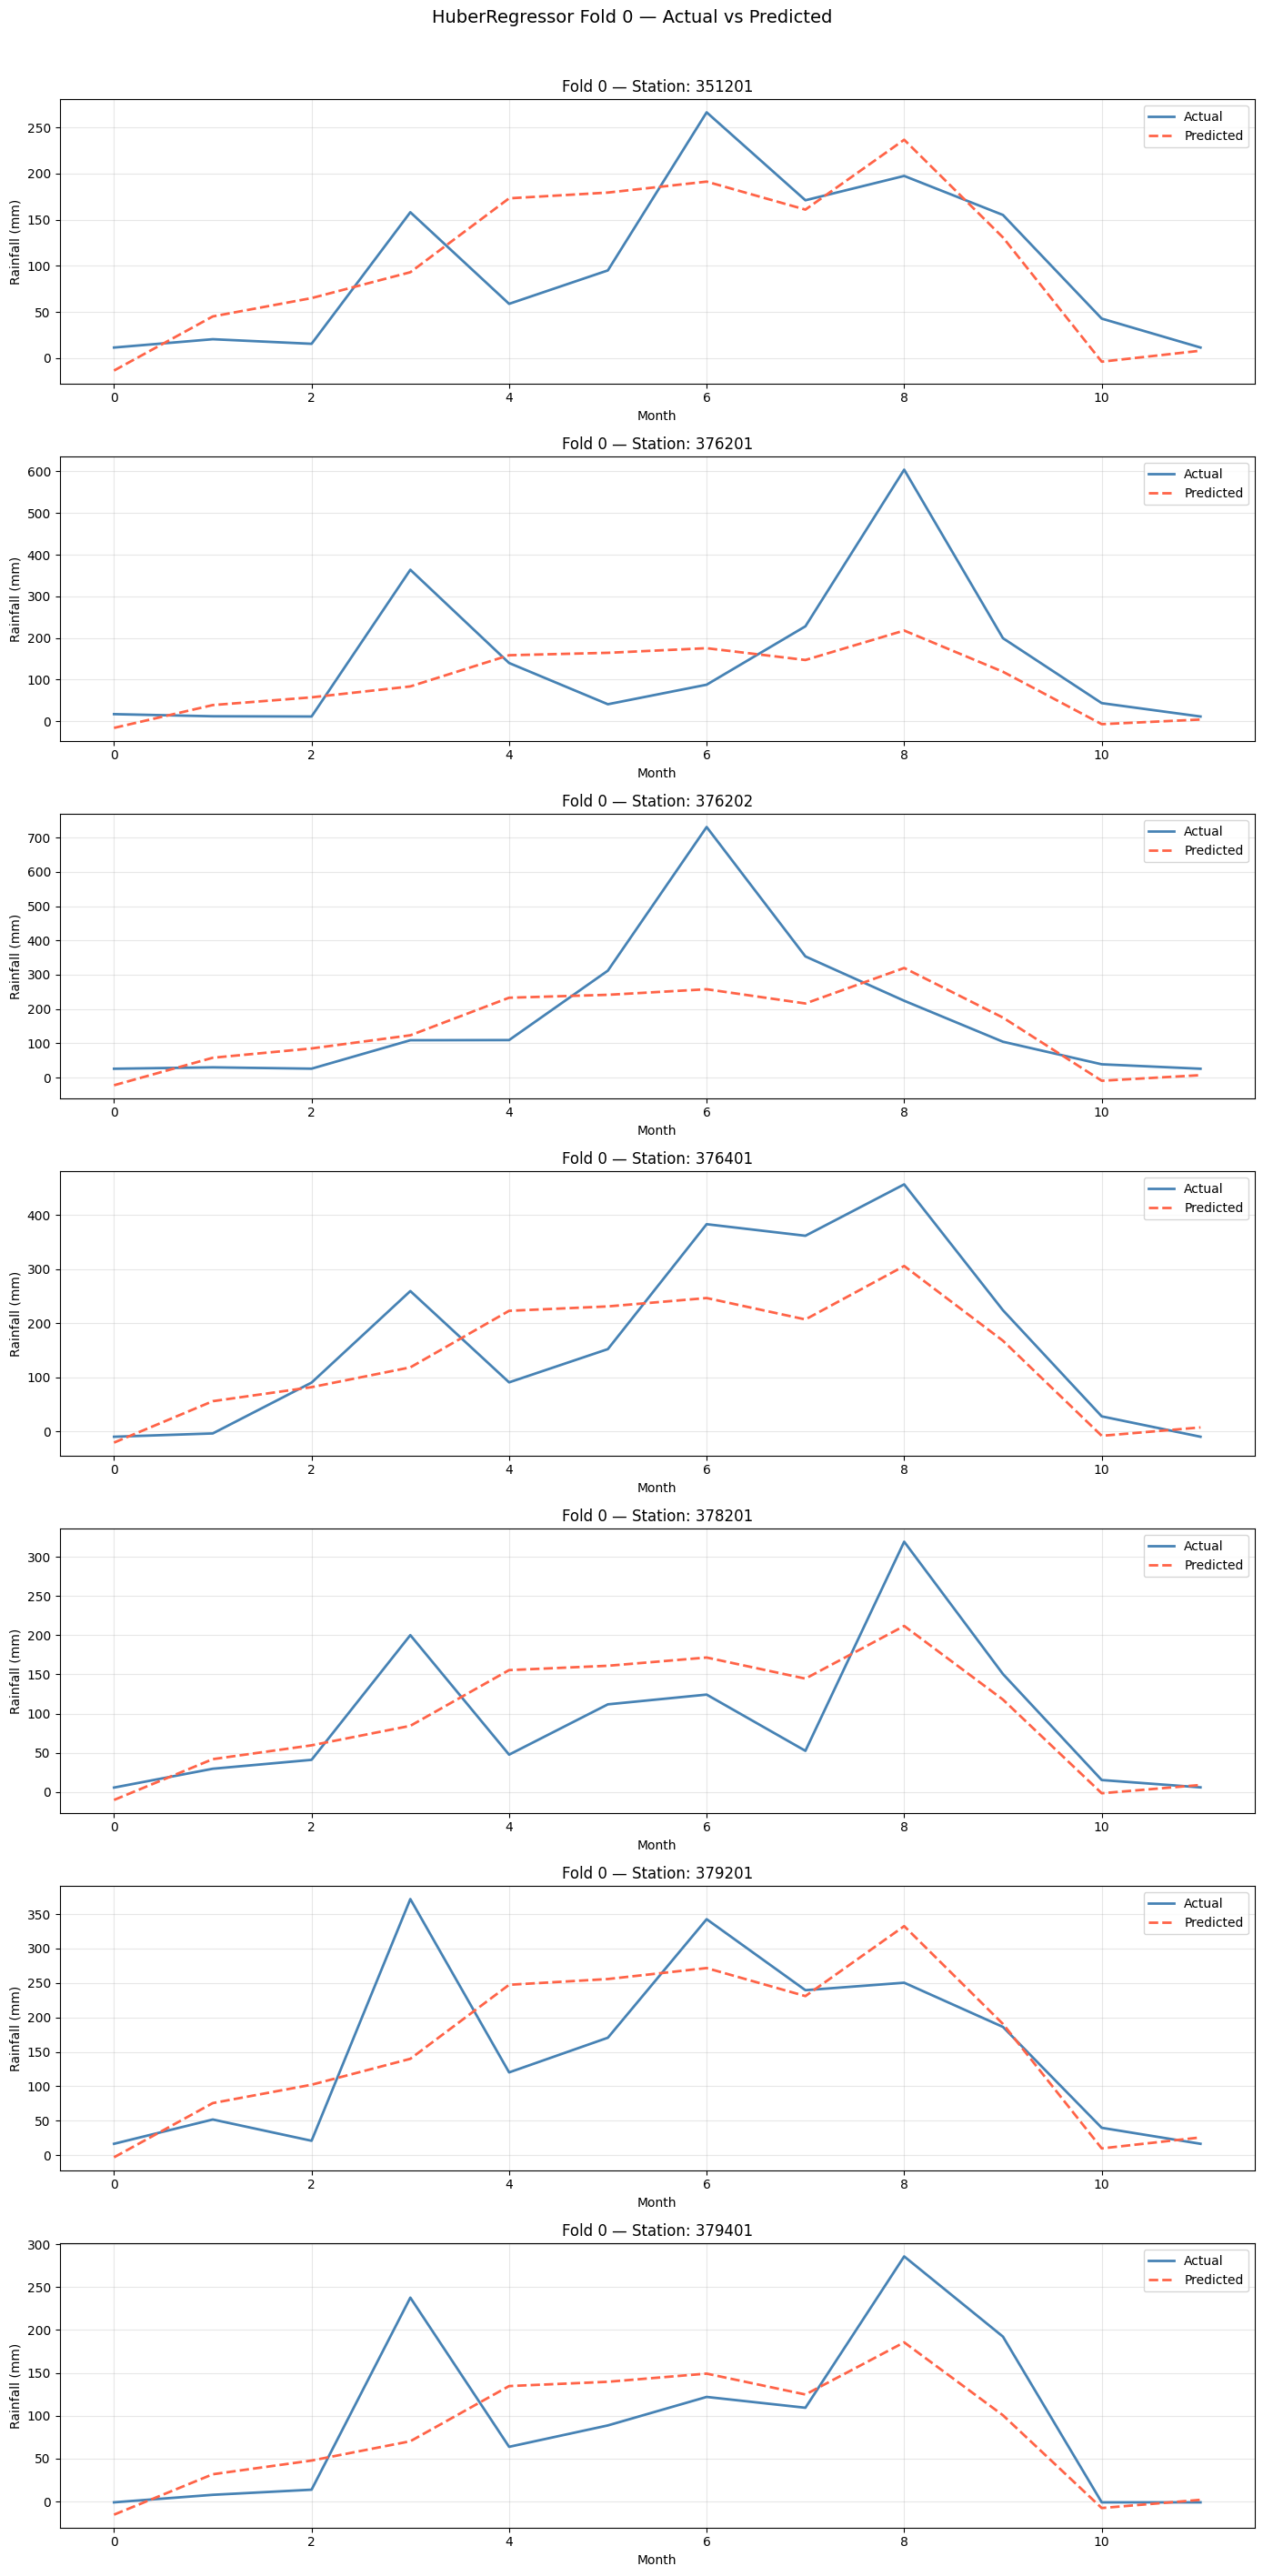

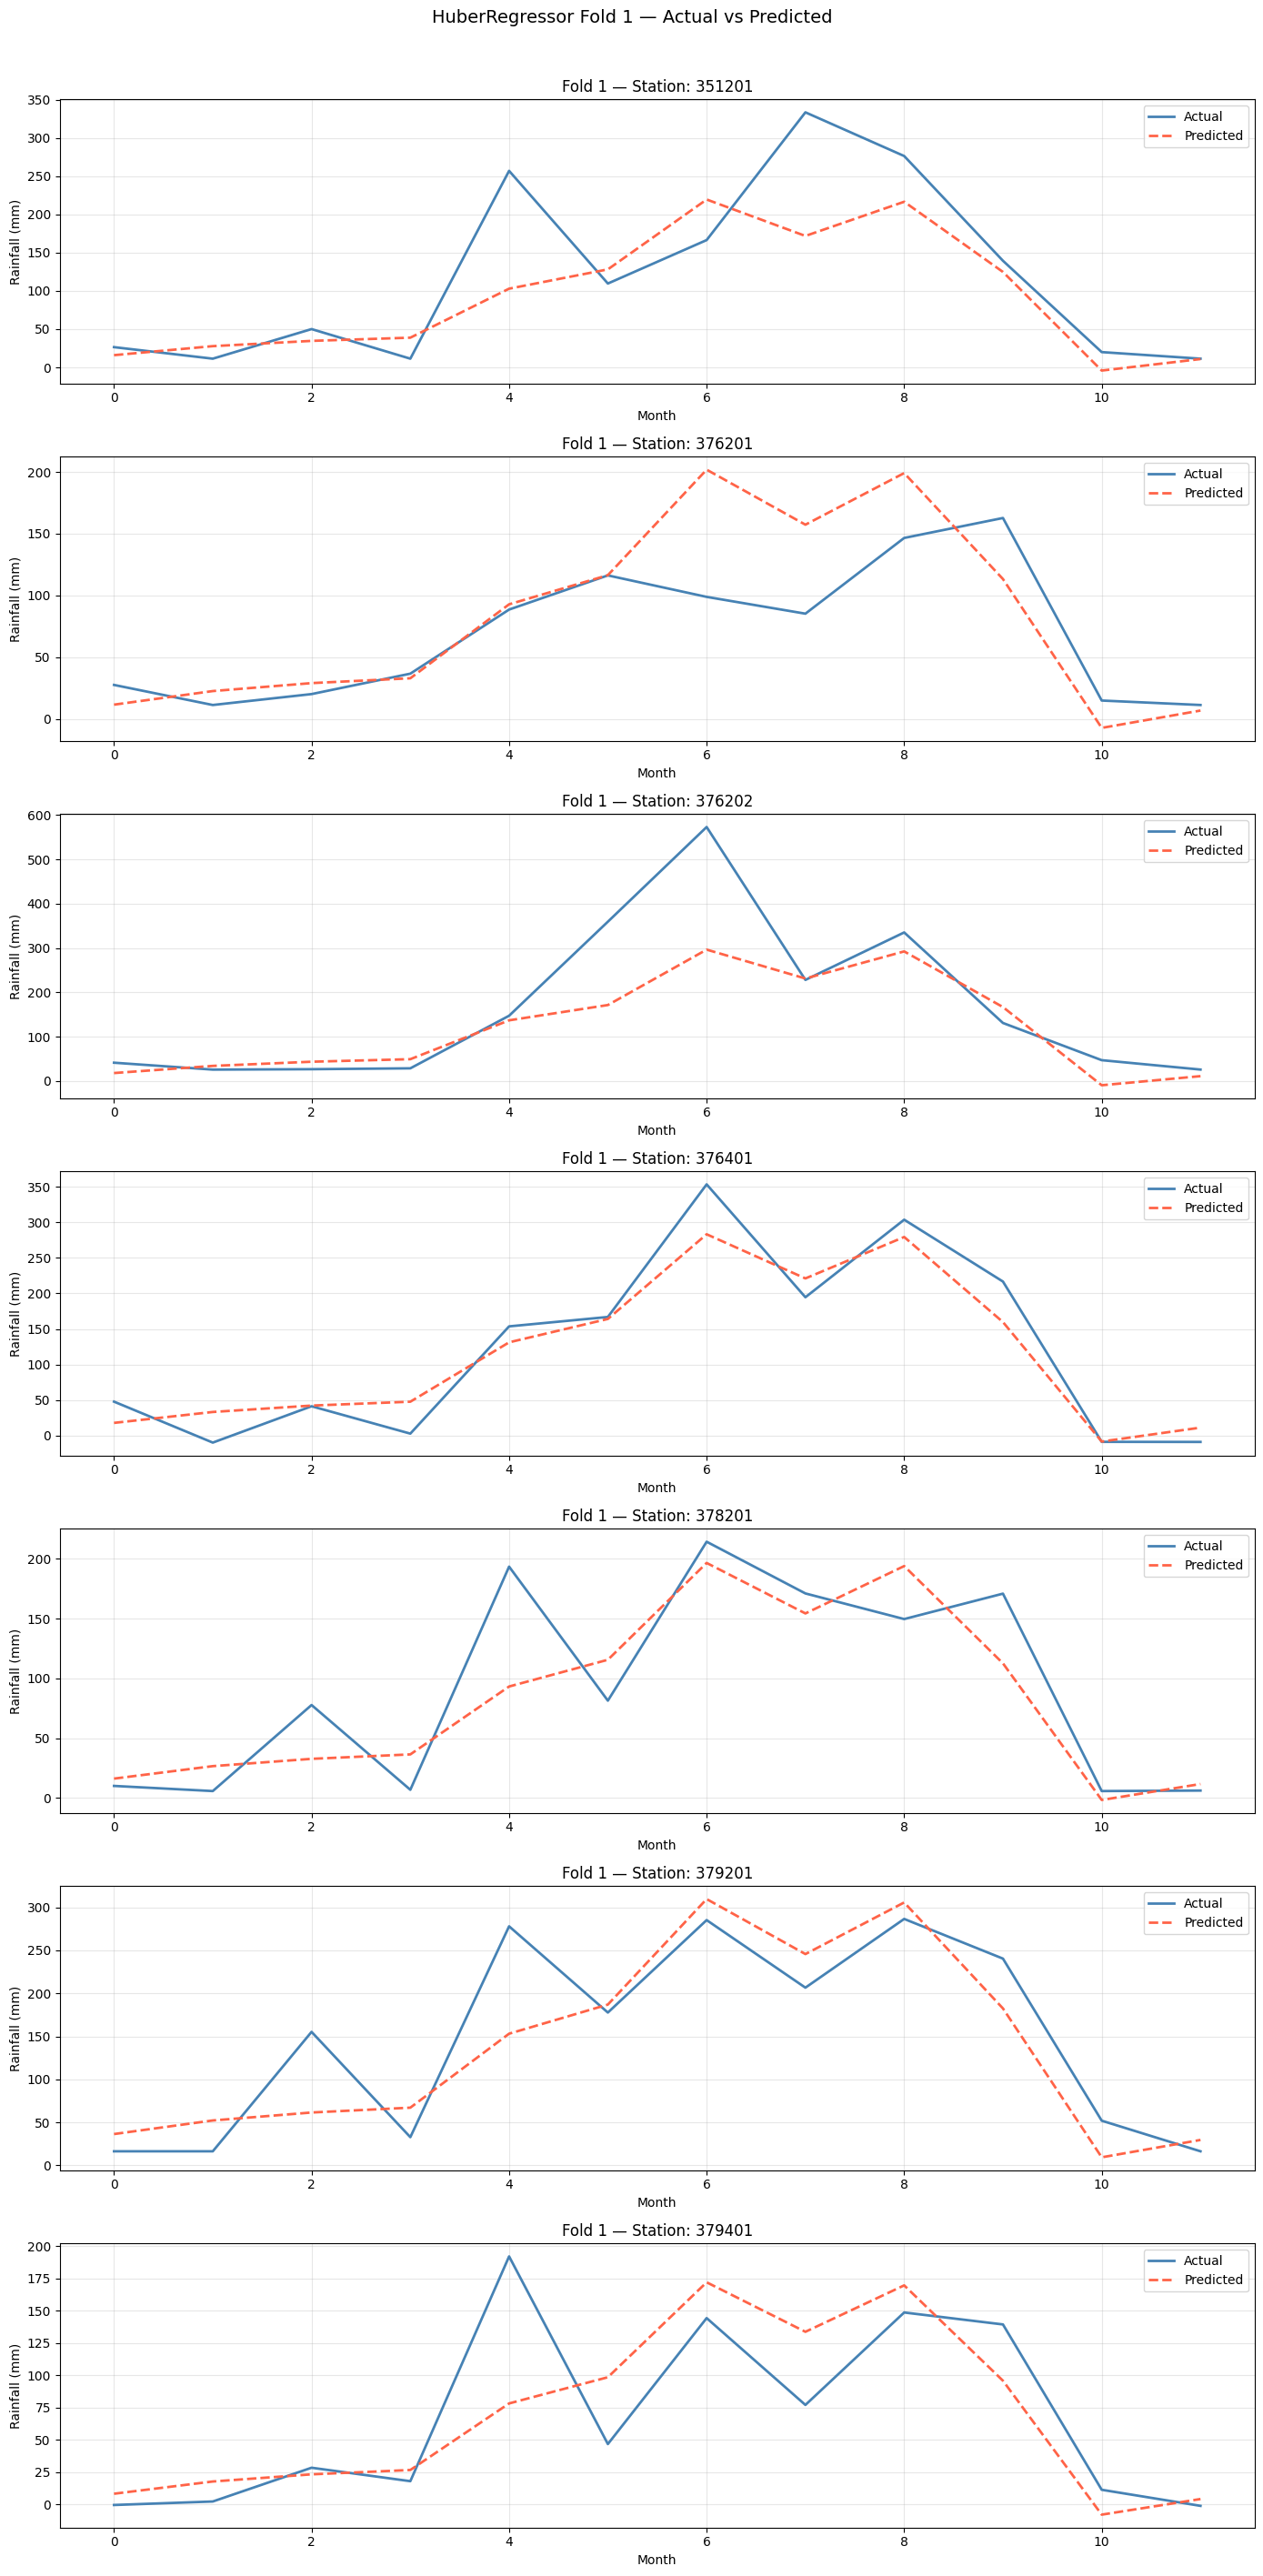


===== ตารางเปรียบเทียบ LSTM vs HuberRegressor =====
 fold_index          Model   RMSE     R2    NSE  acc_month1  acc_month2  acc_month3  acc_month4  acc_month5  acc_month6  acc_month7  acc_month8  acc_month9  acc_month10  acc_month11  acc_month12
          0           LSTM 0.9901 0.3507 0.3709      0.7526      0.8006      0.6283      0.1168      0.1362      0.1120      0.3301      0.4260      0.5367       0.0573       0.8178       0.8598
          1           LSTM 0.5422 0.6499 0.6514      0.8353      0.8384      0.6216      0.5720      0.2152      0.0858      0.3316      0.3705      0.4962       0.4254       0.8982       0.8113
          0 HuberRegressor 0.9279 0.4298 0.4298     76.1539     70.9381     53.6877      7.8249      8.2653      8.4013     30.5852     46.6477     35.6278      36.1729      56.2873      92.2878
          1 HuberRegressor 0.5128 0.6868 0.6868     81.9171     80.5386     62.1347     76.7756      5.5266     37.0771     48.4161     40.0338     57.2304      27.461

In [68]:
# --- กราฟ ---
for fold_index in range(k_fold_num):
    y_pred      = best_estimators[fold_index]['y_pred']
    y_test_fold = best_estimators[fold_index]['y_test']

    fig, axes = plt.subplots(len(cluster_station), 1,
                             figsize=(14, 4 * len(cluster_station)))
    if len(cluster_station) == 1:
        axes = [axes]

    n_windows = len(X_test_fold) // len(cluster_station)

    for i, station in enumerate(cluster_station):
        station_name = node['Node'].iloc[station]
        s = i * n_windows
        e = s + n_windows

        y_true_s = inverse_transform_station_with_nans(
            y_test_fold[s:e].flatten(), i, scaler_Y)
        y_pred_s = inverse_transform_station_with_nans(
            y_pred[s:e].flatten(), i, scaler_Y)

        t = range(len(y_true_s))
        axes[i].plot(t, y_true_s, label='Actual',
                     color='steelblue', linewidth=2)
        axes[i].plot(t, y_pred_s, label='Predicted',
                     color='tomato', linewidth=2, linestyle='--')
        axes[i].set_title(f'Fold {fold_index} — Station: {station_name}')
        axes[i].set_xlabel('Month')
        axes[i].set_ylabel('Rainfall (mm)')
        axes[i].legend()
        axes[i].grid(alpha=0.3)

    plt.suptitle(f'HuberRegressor Fold {fold_index} — Actual vs Predicted',
                 fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# --- ตารางเปรียบเทียบ ---
huber_rows = []
for fold_index in range(k_fold_num):
    row = {'fold_index': fold_index, 'Model': 'HuberRegressor'}
    row.update(best_estimators[fold_index]['metrics'])
    for m in range(horizon):
        row[f'acc_month{m+1}'] = round(
            float(best_estimators[fold_index]['acc_per_month'][m]), 4)
    huber_rows.append(row)

lstm_data = {
    'fold_index': [0, 1],
    'Model': ['LSTM', 'LSTM'],
    'RMSE':  [0.9901, 0.5422],
    'R2':    [0.3507, 0.6499],
    'NSE':   [0.3709, 0.6514],
    'acc_month1':  [0.7526, 0.8353],
    'acc_month2':  [0.8006, 0.8384],
    'acc_month3':  [0.6283, 0.6216],
    'acc_month4':  [0.1168, 0.5720],
    'acc_month5':  [0.1362, 0.2152],
    'acc_month6':  [0.1120, 0.0858],
    'acc_month7':  [0.3301, 0.3316],
    'acc_month8':  [0.4260, 0.3705],
    'acc_month9':  [0.5367, 0.4962],
    'acc_month10': [0.0573, 0.4254],
    'acc_month11': [0.8178, 0.8982],
    'acc_month12': [0.8598, 0.8113],
}

cols = ['fold_index', 'Model', 'RMSE', 'R2', 'NSE'] + \
       [f'acc_month{m+1}' for m in range(horizon)]

compare_df = pd.concat(
    [pd.DataFrame(lstm_data), pd.DataFrame(huber_rows)],
    ignore_index=True
)[cols]

print("\n===== ตารางเปรียบเทียบ LSTM vs HuberRegressor =====")
print(compare_df.to_string(index=False))

compare_df.to_csv(
    '/content/drive/MyDrive/KKU_Workshop3/comparison_LSTM_vs_Huber.csv',
    index=False
)
print("\nบันทึกไฟล์เรียบร้อยแล้ว")